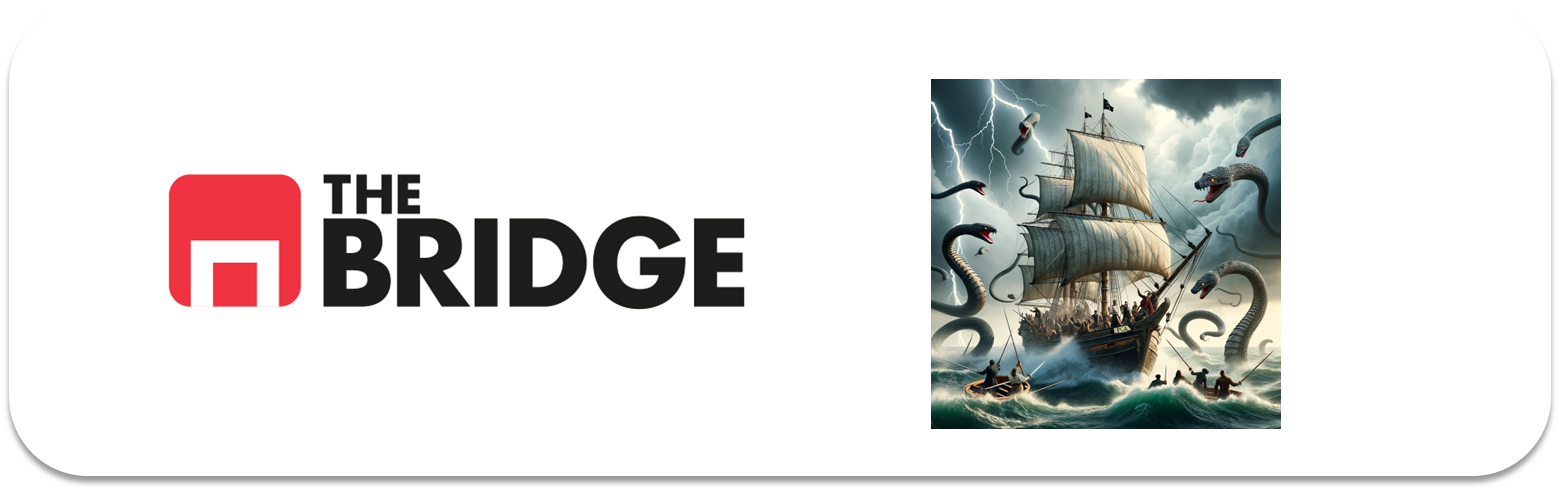

## PRACTICA OBLIGATORIA: **Seleccion Features**

* La práctica obligatoria de esta unidad consiste en hacer una comparativa de diferentes técnicas de selección de features sobre un dataset ya conocido. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Descripción General y Objetivo

El objetivo de la práctica es que juegues con las diferentes técncias de selección de features sobre un problema de clasificación. Para ello, tendrás que cargar el dataset de credit scoring que tienes en la carpeta "data" y que ya hemos trabajado anteriormente. A partir de ahí tendrás que probar diferentes técnicas de selección de features y compararlas todas entre sí y escoger finalmente el conjunto más sencillo con más potencia. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from collections import Counter

from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import (SelectKBest, f_classif, mutual_info_classif,
                                       SelectFromModel, RFE, SequentialFeatureSelector,
                                       VarianceThreshold)
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, ExtraTreesClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import balanced_accuracy_score
from sklearn.decomposition import PCA


### Detalles e Instrucciones

El objetivo es que construyas un modelo final de clasificació sobre la variable "SeriousDlqin2yrs" del dataset que encontrarás en "data".  

Sigue los pasos del proceso de ML que hemos aprendido para problemas supervisados con el dataset que encontrarás en "data" pero con las siguiente salvedades:

1. Deshazte de las filas con nulos, para este ejercicio no nos importan. Convierte las features NumberOf... que creas conveniente a categóricas con 2 o 3 niveles a lo sumo.

2. A la hora de hacer el miniEda aplica los siguientes análisis y selección de features: 
    1. Análisis visual combinado con filtrado por valores de correlación y umbral de covarianza.
    2. Selección de features numéricas mediante SelectKBest y ANOVA, selecció de features categóricas mediante Mutual Information 
    3. Selección de las mejores features a través de un modelo intermedio (usando SelectFromModel)
    4. Selección de las mejores features empleando RFE.
    5. Selección de las mejores features empleando SFS.
    6. Selección de las mejores features mediante un sistema de hard-voting aplicado a lo obtenido en los pasos 1 a 5 anteriores.

    Para cada paso anterior (salvo el 1) se pide obtener una lista de features de "primera división" con un número de variables no superior a 6 (pueden ser menos).

3. Escoge tres modelos y a la hora compararlos para escoger el mejor, entrenalos con validación cruzada empleando las seis listas obtenidas anteriormente. Es decir tendrás 18 (6*3) medidas (emplea la métrica que creas más conveniente y si no se te ocurre ninguna el recall medio).  Escoge el mejor modelo y la mejor selección de features.

4. Optimiza los hiperparámetros del mejor modelo. Evalúalo contra test.


Shape original: (12537, 11)
Nulos por columna:
SeriousDlqin2yrs                          0
RevolvingUtilizationOfUnsecuredLines      0
age                                       0
NumberOfTime30-59DaysPastDueNotWorse      0
DebtRatio                                 0
MonthlyIncome                           721
NumberOfOpenCreditLinesAndLoans           0
NumberOfTimes90DaysLate                   0
NumberRealEstateLoansOrLines              0
NumberOfTime60-89DaysPastDueNotWorse      0
NumberOfDependents                      177
dtype: int64

Shape tras dropna: (11816, 11)

Distribucion target:
SeriousDlqin2yrs
0    10986
1      830
Name: count, dtype: int64
Proporcion positivos: 7.0%  (dataset desbalanceado)

Rangos tras conversion a categoricas (0, 1, 2+):
                                          0     1     2
NumberOfTime30-59DaysPastDueNotWorse   9818  1354   644
NumberOfTimes90DaysLate               11156   394   266
NumberOfTime60-89DaysPastDueNotWorse  11206   478   132
NumberRealE

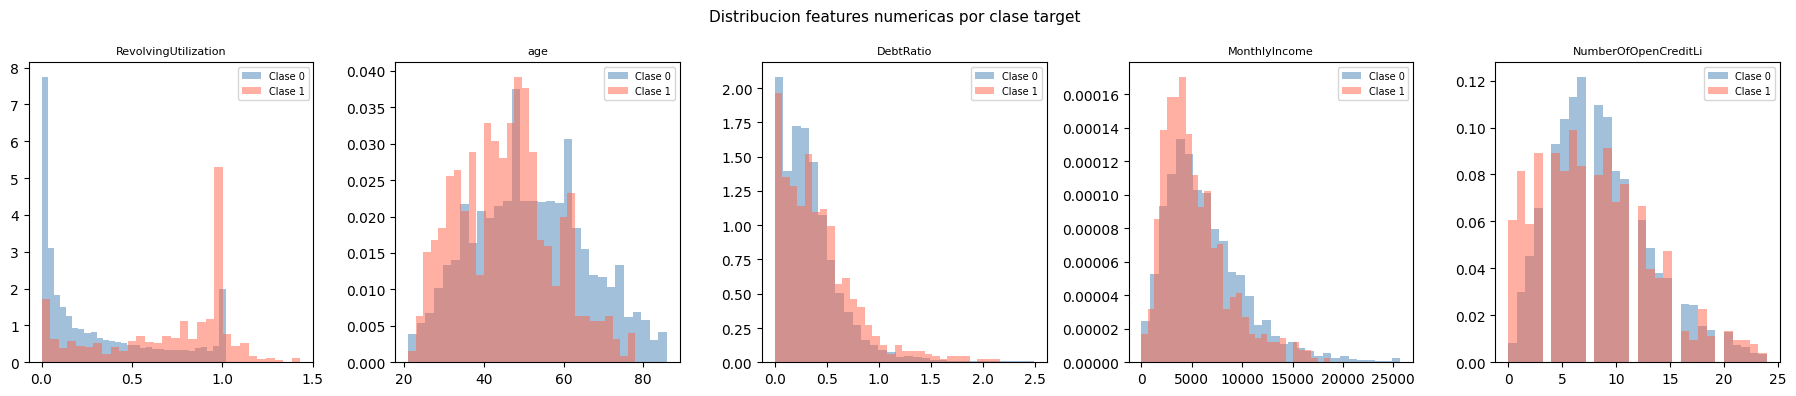


Correlacion |r| con target:
NumberOfTimes90DaysLate                 0.3742
RevolvingUtilizationOfUnsecuredLines    0.2804
NumberOfTime60-89DaysPastDueNotWorse    0.2695
NumberOfTime30-59DaysPastDueNotWorse    0.2575
age                                     0.1061
NumberOfDependents                      0.0490
NumberOfOpenCreditLinesAndLoans         0.0296
NumberRealEstateLoansOrLines            0.0276
MonthlyIncome                           0.0222
DebtRatio                               0.0017
Name: SeriousDlqin2yrs, dtype: float64


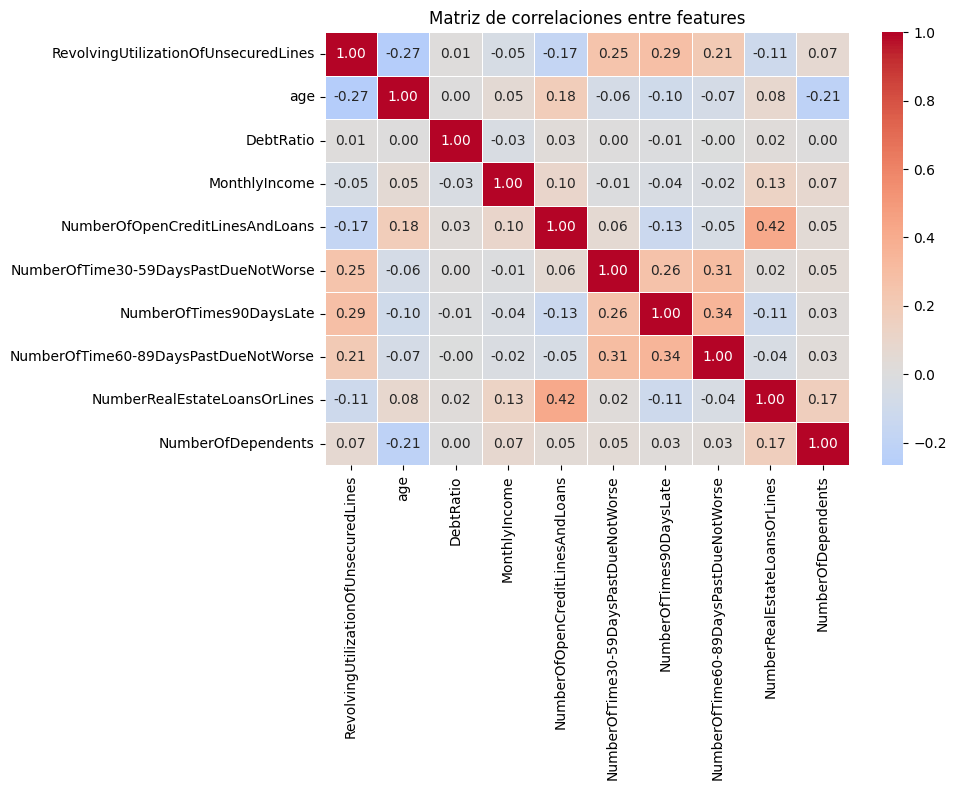

Features numericas con varianza > 0.01: ['RevolvingUtilizationOfUnsecuredLines', 'age', 'DebtRatio', 'MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans']

Lista 1 (visual + correlacion + varianza): ['RevolvingUtilizationOfUnsecuredLines', 'age', 'NumberOfOpenCreditLinesAndLoans', 'MonthlyIncome', 'NumberOfTimes90DaysLate', 'NumberOfTime30-59DaysPastDueNotWorse']

=== PASO 2b: SelectKBest ANOVA + Mutual Information ===
Scores ANOVA (F-statistic):
RevolvingUtilizationOfUnsecuredLines    788.27
age                                     105.86
NumberOfOpenCreditLinesAndLoans          10.63
MonthlyIncome                             6.12
DebtRatio                                 0.00
dtype: float64
Top 4 numericas por ANOVA: ['RevolvingUtilizationOfUnsecuredLines', 'age', 'MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans']

MI scores categoricas:
NumberOfTimes90DaysLate                 0.0356
NumberOfTime30-59DaysPastDueNotWorse    0.0234
NumberOfTime60-89DaysPastDueNotWorse    0.0205
NumberRea

Importancias RF:
 RevolvingUtilizationOfUnsecuredLines    0.2723
DebtRatio                               0.1334
MonthlyIncome                           0.1251
age                                     0.1234
NumberOfOpenCreditLinesAndLoans         0.0868
NumberOfTimes90DaysLate                 0.0849
NumberOfTime30-59DaysPastDueNotWorse    0.0744
NumberOfTime60-89DaysPastDueNotWorse    0.0495
NumberOfDependents                      0.0266
NumberRealEstateLoansOrLines            0.0236
dtype: float64

Lista 3 (SelectFromModel): ['RevolvingUtilizationOfUnsecuredLines', 'DebtRatio', 'MonthlyIncome', 'age', 'NumberOfOpenCreditLinesAndLoans']

=== PASO 2d: RFE ===


                             feature  ranking
RevolvingUtilizationOfUnsecuredLines        1
                                 age        1
                           DebtRatio        1
                       MonthlyIncome        1
     NumberOfOpenCreditLinesAndLoans        1
             NumberOfTimes90DaysLate        1
NumberOfTime30-59DaysPastDueNotWorse        2
NumberOfTime60-89DaysPastDueNotWorse        3
                  NumberOfDependents        4
        NumberRealEstateLoansOrLines        5

Lista 4 (RFE): ['RevolvingUtilizationOfUnsecuredLines', 'age', 'DebtRatio', 'MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate']

=== PASO 2e: SFS ===


Lista 5 (SFS): ['NumberOfTime30-59DaysPastDueNotWorse', 'NumberOfTimes90DaysLate', 'NumberOfTime60-89DaysPastDueNotWorse', 'NumberRealEstateLoansOrLines', 'NumberOfDependents']

=== PASO 2f: Hard-voting ===
Votos por feature:
                                      votos
RevolvingUtilizationOfUnsecuredLines      4
age                                       4
NumberOfOpenCreditLinesAndLoans           4
MonthlyIncome                             4
NumberOfTimes90DaysLate                   4
NumberOfTime30-59DaysPastDueNotWorse      3
DebtRatio                                 2
NumberOfTime60-89DaysPastDueNotWorse      1
NumberRealEstateLoansOrLines              1
NumberOfDependents                        1

Lista 6 (Hard-voting, max 6): ['RevolvingUtilizationOfUnsecuredLines', 'age', 'NumberOfOpenCreditLinesAndLoans', 'MonthlyIncome', 'NumberOfTimes90DaysLate', 'NumberOfTime30-59DaysPastDueNotWorse']

=== RESUMEN 6 LISTAS ===
  L1_visual_corr: ['RevolvingUtilizationOfUnsecuredLines', 'age', 

L1_visual_corr  | LogisticReg : 0.7681


...

L5_SFS          | RandomForest: 0.7067


L5_SFS          | ExtraTrees  : 0.7082


L6_voting       | LogisticReg : 0.7681


L6_voting       | RandomForest: 0.5881


L6_voting       | ExtraTrees  : 0.5884

Tabla comparativa:
modelo          ExtraTrees  LogisticReg  RandomForest
lista                                                
L1_visual_corr      0.5884       0.7681        0.5881
L2_ANOVA_MI         0.5908       0.7681        0.5839
L3_SFM              0.5164       0.7309        0.5191
L4_RFE              0.5877       0.7434        0.5790
L5_SFS              0.7082       0.7430        0.7067
L6_voting           0.5884       0.7681        0.5881

MEJOR: LogisticReg con L1_visual_corr -> CV=0.7681


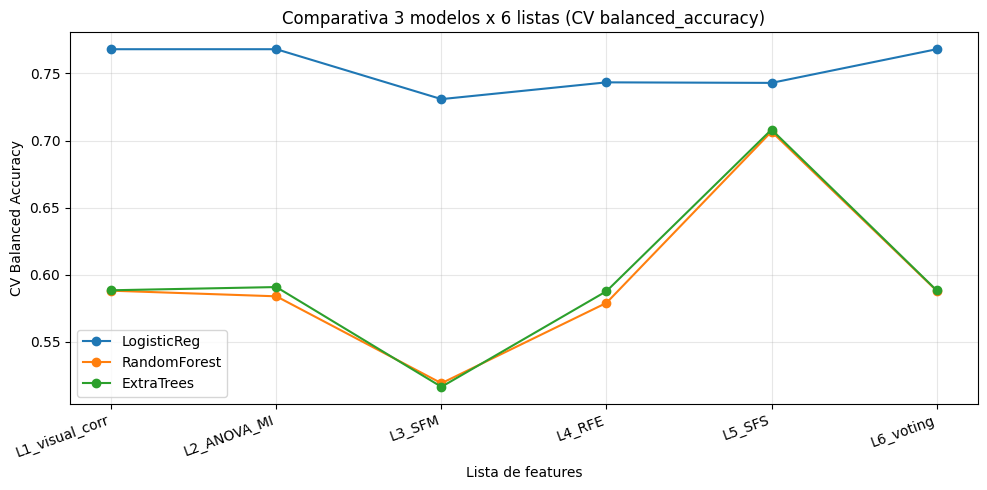


=== PASO 4: Optimizacion hiperparametros ===


Mejores hiperparametros: {'solver': 'liblinear', 'penalty': 'l1', 'class_weight': 'balanced', 'C': 1}
Mejor CV score (tuning): 0.7680

Test balanced_accuracy (modelo final): 0.7627 (76.27%)
Features seleccionadas: ['RevolvingUtilizationOfUnsecuredLines', 'age', 'NumberOfOpenCreditLinesAndLoans', 'MonthlyIncome', 'NumberOfTimes90DaysLate', 'NumberOfTime30-59DaysPastDueNotWorse'] (6 features)
Reduccion features: 10 -> 6 (60% del total)


In [2]:
# ============================================================
# PASO 1: Carga, limpieza y feature engineering
# ============================================================
df = pd.read_csv("./data/credit_npo.csv")
print(f"Shape original: {df.shape}")
print(f"Nulos por columna:\n{df.isnull().sum()}")

# Eliminar filas con nulos (instruccion del enunciado)
df.dropna(inplace=True)
print(f"\nShape tras dropna: {df.shape}")

TARGET = 'SeriousDlqin2yrs'
print(f"\nDistribucion target:\n{df[TARGET].value_counts()}")
print(f"Proporcion positivos: {df[TARGET].mean()*100:.1f}%  (dataset desbalanceado)")

# Convertir NumberOf... a categoricas con 3 niveles: 0, 1, 2+
# Los valores 96/98 son errores de datos -> se capan a 2
NUMBEROF_COLS = [
    'NumberOfTime30-59DaysPastDueNotWorse',
    'NumberOfTimes90DaysLate',
    'NumberOfTime60-89DaysPastDueNotWorse',
    'NumberRealEstateLoansOrLines',
    'NumberOfDependents',
]
for col in NUMBEROF_COLS:
    df[col] = df[col].apply(lambda x: min(int(x), 2))

print("\nRangos tras conversion a categoricas (0, 1, 2+):")
print(df[NUMBEROF_COLS].apply(lambda c: c.value_counts().sort_index()).T)

# Separar features numericas y categoricas
NUM_FEATURES = [
    'RevolvingUtilizationOfUnsecuredLines',
    'age',
    'DebtRatio',
    'MonthlyIncome',
    'NumberOfOpenCreditLinesAndLoans',
]
CAT_FEATURES = NUMBEROF_COLS
ALL_FEATURES = NUM_FEATURES + CAT_FEATURES

X = df[ALL_FEATURES]
y = df[TARGET]

# Split estratificado 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"\nTrain: {X_train.shape}  |  Test: {X_test.shape}")

# ============================================================
# PASO 2a: Analisis visual + correlacion + varianza
# ============================================================
print("\n=== PASO 2a: Analisis visual, correlacion y varianza ===")

# Distribucion de features numericas por clase target
fig, axes = plt.subplots(1, len(NUM_FEATURES), figsize=(18, 4))
for ax, feat in zip(axes, NUM_FEATURES):
    for clase, color in zip([0, 1], ['steelblue', 'tomato']):
        vals = X_train.loc[y_train == clase, feat]
        # recortar outliers para visualizar
        q99 = vals.quantile(0.99)
        ax.hist(vals[vals <= q99], bins=30, alpha=0.5, color=color, label=f'Clase {clase}', density=True)
    ax.set_title(feat[:20], fontsize=8)
    ax.legend(fontsize=7)
plt.suptitle("Distribucion features numericas por clase target", fontsize=11)
plt.tight_layout()
plt.show()

# Correlacion con target
corr_all = df[ALL_FEATURES + [TARGET]].corr()
corr_target = corr_all[TARGET].drop(TARGET).abs().sort_values(ascending=False)
print("\nCorrelacion |r| con target:")
print(corr_target.round(4))

# Heatmap de correlaciones entre features
plt.figure(figsize=(10, 8))
sns.heatmap(X_train.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0, linewidths=0.5)
plt.title("Matriz de correlaciones entre features")
plt.tight_layout()
plt.show()

# Umbral de varianza (solo features numericas, no supervisado)
vt = VarianceThreshold(threshold=0.01)
vt.fit(X_train[NUM_FEATURES])
features_varianza = vt.get_feature_names_out().tolist()
print(f"Features numericas con varianza > 0.01: {features_varianza}")

# LISTA 1: correlacion + varianza
# Top 4 numericas por correlacion con target
top_num_corr = [f for f in corr_target.index if f in NUM_FEATURES][:4]
# Top 2 categoricas: anticipo de MI para la lista 1
mi_cat_preview = pd.Series(
    mutual_info_classif(X_train[CAT_FEATURES], y_train, discrete_features=True, random_state=42),
    index=CAT_FEATURES
).sort_values(ascending=False)
top_cat_mi = mi_cat_preview.head(2).index.tolist()

features_lista1 = list(dict.fromkeys(top_num_corr + top_cat_mi))[:6]
print(f"\nLista 1 (visual + correlacion + varianza): {features_lista1}")

# ============================================================
# PASO 2b: SelectKBest ANOVA (numericas) + Mutual Information (categoricas)
# ============================================================
print("\n=== PASO 2b: SelectKBest ANOVA + Mutual Information ===")

# ANOVA para features numericas
selector_anova = SelectKBest(f_classif, k=4)
selector_anova.fit(X_train[NUM_FEATURES], y_train)
features_anova = selector_anova.get_feature_names_out().tolist()
f_scores = pd.Series(selector_anova.scores_, index=NUM_FEATURES).sort_values(ascending=False)
print(f"Scores ANOVA (F-statistic):\n{f_scores.round(2)}")
print(f"Top 4 numericas por ANOVA: {features_anova}")

# Mutual Information para features categoricas
mi_scores = pd.Series(
    mutual_info_classif(X_train[CAT_FEATURES], y_train, discrete_features=True, random_state=42),
    index=CAT_FEATURES
).sort_values(ascending=False)
print(f"\nMI scores categoricas:\n{mi_scores.round(4)}")
features_mi = mi_scores.head(2).index.tolist()
print(f"Top 2 categoricas por MI: {features_mi}")

features_lista2 = list(dict.fromkeys(features_anova + features_mi))[:6]
print(f"\nLista 2 (ANOVA + MI): {features_lista2}")

# ============================================================
# PASO 2c: SelectFromModel
# ============================================================
print("\n=== PASO 2c: SelectFromModel (RF intermedio) ===")

rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1,
                                   class_weight='balanced')
rf_model.fit(X_train, y_train)

importancias = pd.Series(rf_model.feature_importances_, index=ALL_FEATURES).sort_values(ascending=False)
print("Importancias RF:\n", importancias.round(4))

# Usar mediana como umbral -> features con importancia >= mediana
# (equivalente a SelectFromModel threshold='median' pero sin el bug de prefit)
umbral_median = importancias.median()
features_sfm = importancias[importancias >= umbral_median].index.tolist()[:6]

features_lista3 = features_sfm
print(f"\nLista 3 (SelectFromModel): {features_lista3}")

# ============================================================
# PASO 2d: RFE (Recursive Feature Elimination)
# ============================================================
print("\n=== PASO 2d: RFE ===")

rf_rfe = RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1,
                                 class_weight='balanced')
rfe = RFE(estimator=rf_rfe, n_features_to_select=6, step=1)
rfe.fit(X_train, y_train)

rfe_df = pd.DataFrame({'feature': ALL_FEATURES, 'ranking': rfe.ranking_}).sort_values('ranking')
print(rfe_df.to_string(index=False))

features_lista4 = rfe.get_feature_names_out().tolist()
print(f"\nLista 4 (RFE): {features_lista4}")

# ============================================================
# PASO 2e: SFS (Sequential Feature Selector)
# ============================================================
print("\n=== PASO 2e: SFS ===")

rf_sfs = RandomForestClassifier(n_estimators=30, random_state=42, n_jobs=-1,
                                 class_weight='balanced')
sfs = SequentialFeatureSelector(
    rf_sfs,
    n_features_to_select=5,
    direction='forward',
    cv=3,
    scoring='balanced_accuracy',
    n_jobs=-1
)
sfs.fit(X_train, y_train)
features_lista5 = sfs.get_feature_names_out().tolist()
print(f"Lista 5 (SFS): {features_lista5}")

# ============================================================
# PASO 2f: Hard-voting sobre las 5 listas anteriores
# ============================================================
print("\n=== PASO 2f: Hard-voting ===")

todos_votos = (features_lista1 + features_lista2 + features_lista3 +
               features_lista4 + features_lista5)
conteo = Counter(todos_votos)
df_votos = pd.DataFrame.from_dict(conteo, orient='index', columns=['votos']).sort_values('votos', ascending=False)
print("Votos por feature:")
print(df_votos)

features_lista6 = df_votos.head(6).index.tolist()
print(f"\nLista 6 (Hard-voting, max 6): {features_lista6}")

# Resumen de las 6 listas
print("\n=== RESUMEN 6 LISTAS ===")
listas = {
    'L1_visual_corr' : features_lista1,
    'L2_ANOVA_MI'    : features_lista2,
    'L3_SFM'         : features_lista3,
    'L4_RFE'         : features_lista4,
    'L5_SFS'         : features_lista5,
    'L6_voting'      : features_lista6,
}
for nombre, lista in listas.items():
    print(f"  {nombre}: {lista}")

# ============================================================
# PASO 3: 3 modelos x 6 listas = 18 comparaciones CV
# ============================================================
print("\n=== PASO 3: 18 comparaciones CV (balanced_accuracy) ===")

modelos_comp = {
    'LogisticReg': LogisticRegression(max_iter=500, random_state=42, class_weight='balanced'),
    'RandomForest': RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1, class_weight='balanced'),
    'ExtraTrees':  ExtraTreesClassifier(n_estimators=50, random_state=42, n_jobs=-1, class_weight='balanced'),
}

resultados = []
for nombre_lista, feats in listas.items():
    for nombre_mod, modelo in modelos_comp.items():
        cv_score = cross_val_score(modelo, X_train[feats], y_train,
                                    cv=5, scoring='balanced_accuracy').mean()
        resultados.append({'lista': nombre_lista, 'modelo': nombre_mod,
                           'cv_balanced_acc': round(cv_score, 4)})
        print(f"{nombre_lista:15s} | {nombre_mod:12s}: {cv_score:.4f}")

df_res = pd.DataFrame(resultados)
pivot = df_res.pivot(index='lista', columns='modelo', values='cv_balanced_acc')
print("\nTabla comparativa:")
print(pivot.to_string())

# Mejor combinacion
idx_mejor = df_res['cv_balanced_acc'].idxmax()
mejor = df_res.loc[idx_mejor]
print(f"\nMEJOR: {mejor['modelo']} con {mejor['lista']} -> CV={mejor['cv_balanced_acc']:.4f}")

mejor_lista_nombre = mejor['lista']
mejor_lista = listas[mejor_lista_nombre]
mejor_modelo_nombre = mejor['modelo']

# Grafico comparativo
fig, ax = plt.subplots(figsize=(10, 5))
for nombre_mod in modelos_comp:
    sub = df_res[df_res['modelo'] == nombre_mod]
    ax.plot(sub['lista'], sub['cv_balanced_acc'], 'o-', label=nombre_mod)
ax.set_xlabel("Lista de features")
ax.set_ylabel("CV Balanced Accuracy")
ax.set_title("Comparativa 3 modelos x 6 listas (CV balanced_accuracy)")
ax.legend(); ax.grid(True, alpha=0.3)
plt.xticks(rotation=20, ha='right')
plt.tight_layout(); plt.show()

# ============================================================
# PASO 4: Optimizacion hiperparametros + evaluacion en test
# ============================================================
print("\n=== PASO 4: Optimizacion hiperparametros ===")

param_grids = {
    'LogisticReg': {
        'C': [0.01, 0.1, 1, 10],
        'penalty': ['l1', 'l2'],
        'solver': ['liblinear'],
        'class_weight': ['balanced', None],
    },
    'RandomForest': {
        'n_estimators': [100, 200, 300],
        'max_depth': [None, 5, 10, 15],
        'min_samples_split': [2, 5, 10],
        'class_weight': ['balanced', None],
    },
    'ExtraTrees': {
        'n_estimators': [100, 200, 300],
        'max_depth': [None, 5, 10, 15],
        'min_samples_split': [2, 5, 10],
        'class_weight': ['balanced', None],
    },
}
modelos_base = {
    'LogisticReg': LogisticRegression(max_iter=1000, random_state=42),
    'RandomForest': RandomForestClassifier(random_state=42, n_jobs=-1),
    'ExtraTrees': ExtraTreesClassifier(random_state=42, n_jobs=-1),
}

modelo_opt = RandomizedSearchCV(
    modelos_base[mejor_modelo_nombre],
    param_distributions=param_grids[mejor_modelo_nombre],
    n_iter=20,
    cv=5,
    scoring='balanced_accuracy',
    random_state=42,
    n_jobs=-1
)
modelo_opt.fit(X_train[mejor_lista], y_train)
print(f"Mejores hiperparametros: {modelo_opt.best_params_}")
print(f"Mejor CV score (tuning): {modelo_opt.best_score_:.4f}")

# Evaluacion en test
y_pred = modelo_opt.predict(X_test[mejor_lista])
test_score = balanced_accuracy_score(y_test, y_pred)
print(f"\nTest balanced_accuracy (modelo final): {test_score:.4f} ({test_score*100:.2f}%)")
print(f"Features seleccionadas: {mejor_lista} ({len(mejor_lista)} features)")
print(f"Reduccion features: {len(ALL_FEATURES)} -> {len(mejor_lista)} ({len(mejor_lista)/len(ALL_FEATURES)*100:.0f}% del total)")


### EXTRA

Aplica la PCA como método de selección, escoge un número de componentes en función de la varianza explicada y crea un dataset con el que entrenar el mismo tipo de modelo ganador de la parte general. Entrenalo y evalúalo contra test, comenta el resultado.

=== EXTRA: PCA como metodo de seleccion ===


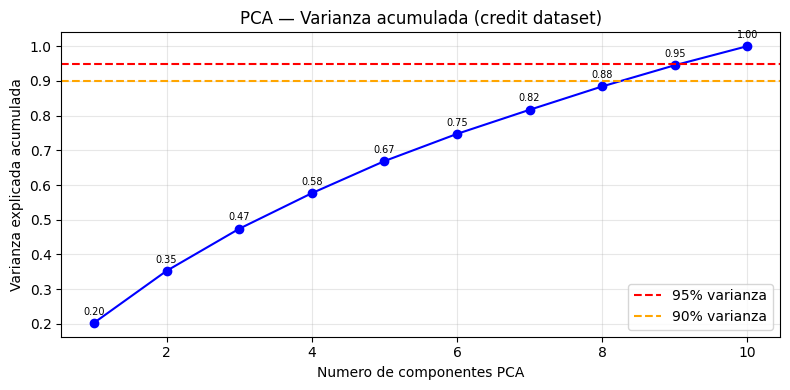

Componentes para 90% varianza: 9
Componentes para 95% varianza: 10
Total features originales: 10
Compresion con 10 PCs: 10/10 = 100.0%

CV balanced_accuracy con PCA (10 PCs): 0.7763


Test balanced_accuracy con PCA:              0.7731
Test balanced_accuracy sin PCA (modelo opt): 0.7627

Diferencia (PCA - seleccion directa): +0.0103 (+1.03pp)


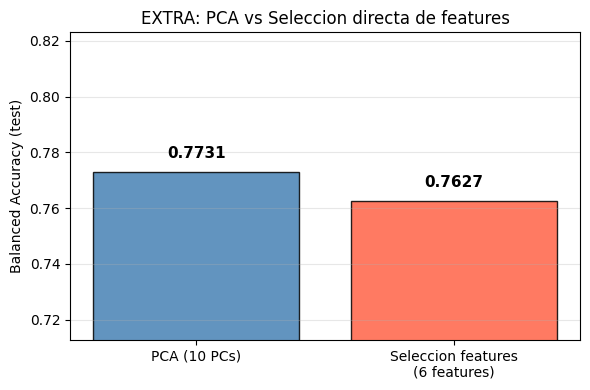


Conclusiones:
- PCA con 10 componentes mejora el rendimiento en 1.03pp.
- Ventaja PCA: captura varianza maxima, util si hay muchas features correladas.
- Desventaja PCA: pierde interpretabilidad (las PCs son combinaciones lineales).
- La seleccion directa de features es mas interpretable para el negocio.


In [3]:
# ============================================================
# EXTRA: PCA como metodo de seleccion de features
# ============================================================
print("=== EXTRA: PCA como metodo de seleccion ===")

# PCA requiere escalado previo
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# PCA completo para analizar varianza acumulada
pca_full = PCA()
pca_full.fit(X_train_scaled)

var_acum = pca_full.explained_variance_ratio_.cumsum()
plt.figure(figsize=(8, 4))
plt.plot(range(1, len(var_acum)+1), var_acum, 'bo-', markersize=6)
plt.axhline(y=0.95, color='red',    linestyle='--', label='95% varianza')
plt.axhline(y=0.90, color='orange', linestyle='--', label='90% varianza')
for i, v in enumerate(var_acum):
    plt.annotate(f'{v:.2f}', (i+1, v), textcoords='offset points', xytext=(0, 6), fontsize=7, ha='center')
plt.xlabel("Numero de componentes PCA")
plt.ylabel("Varianza explicada acumulada")
plt.title("PCA — Varianza acumulada (credit dataset)")
plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

# Seleccionar n_components para 95% de varianza
n_comp_95 = int(np.argmax(var_acum >= 0.95)) + 1
n_comp_90 = int(np.argmax(var_acum >= 0.90)) + 1
print(f"Componentes para 90% varianza: {n_comp_90}")
print(f"Componentes para 95% varianza: {n_comp_95}")
print(f"Total features originales: {X_train.shape[1]}")
print(f"Compresion con {n_comp_95} PCs: {n_comp_95}/{X_train.shape[1]} = {n_comp_95/X_train.shape[1]*100:.1f}%")

# Aplicar PCA con n_components seleccionado (95%)
pca = PCA(n_components=n_comp_95)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca  = pca.transform(X_test_scaled)

# Instanciar el mismo tipo de modelo ganador de Paso 3 con hiperparametros base
modelo_pca_base = {
    'LogisticReg': LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'),
    'RandomForest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1, class_weight='balanced'),
    'ExtraTrees': ExtraTreesClassifier(n_estimators=100, random_state=42, n_jobs=-1, class_weight='balanced'),
}[mejor_modelo_nombre]

# CV con PCA
cv_pca = cross_val_score(modelo_pca_base, X_train_pca, y_train, cv=5,
                          scoring='balanced_accuracy').mean()
print(f"\nCV balanced_accuracy con PCA ({n_comp_95} PCs): {cv_pca:.4f}")

# Entrenar y evaluar en test
modelo_pca_base.fit(X_train_pca, y_train)
test_pca = balanced_accuracy_score(y_test, modelo_pca_base.predict(X_test_pca))
print(f"Test balanced_accuracy con PCA:              {test_pca:.4f}")
print(f"Test balanced_accuracy sin PCA (modelo opt): {test_score:.4f}")

diff = test_pca - test_score
print(f"\nDiferencia (PCA - seleccion directa): {diff:+.4f} ({diff*100:+.2f}pp)")

# Grafico comparativo
labels = [f'PCA ({n_comp_95} PCs)', f'Seleccion features\n({len(mejor_lista)} features)']
values = [test_pca, test_score]
colors = ['steelblue', 'tomato']
fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(labels, values, color=colors, alpha=0.85, edgecolor='black')
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{val:.4f}', ha='center', fontsize=11, fontweight='bold')
ax.set_ylim(min(values) - 0.05, max(values) + 0.05)
ax.set_ylabel("Balanced Accuracy (test)")
ax.set_title("EXTRA: PCA vs Seleccion directa de features")
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout(); plt.show()

print("\nConclusiones:")
print(f"- PCA con {n_comp_95} componentes {'mejora' if diff > 0 else 'reduce'} el rendimiento en {abs(diff)*100:.2f}pp.")
print("- Ventaja PCA: captura varianza maxima, util si hay muchas features correladas.")
print("- Desventaja PCA: pierde interpretabilidad (las PCs son combinaciones lineales).")
print("- La seleccion directa de features es mas interpretable para el negocio.")
